In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("M30 Online Retail.csv", encoding='ISO-8859-1')

In [3]:
df.head()

,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2019 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2019 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2019 08:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   INVOICE_NO    541909 non-null  object 
 1   STOCK_CODE    541909 non-null  object 
 2   DESCRIPTION   540455 non-null  object 
 3   QUANTITY      541909 non-null  int64  
 4   INVOICE_DATE  541909 non-null  object 
 5   UNIT_PRICE    541909 non-null  float64
 6   CUSTOMER_ID   406829 non-null  float64
 7   REGION        541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,QUANTITY,UNIT_PRICE,CUSTOMER_ID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
df = df.dropna(subset=['CUSTOMER_ID'])

In [8]:
df['INVOICE_DATE'] = pd.to_datetime(df['INVOICE_DATE'], dayfirst=True)

In [9]:
df.head()

,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2019-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2019-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2019-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2019-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2019-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   INVOICE_NO    406829 non-null  object        
 1   STOCK_CODE    406829 non-null  object        
 2   DESCRIPTION   406829 non-null  object        
 3   QUANTITY      406829 non-null  int64         
 4   INVOICE_DATE  406829 non-null  datetime64[ns]
 5   UNIT_PRICE    406829 non-null  float64       
 6   CUSTOMER_ID   406829 non-null  float64       
 7   REGION        406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [11]:
df['INVOICE_DATE'].max()

Timestamp('2020-12-09 12:50:00')

In [12]:
reference_date = df['INVOICE_DATE'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2020-12-10 12:50:00')

In [14]:
df['TOTAL_AMOUNT'] = df['QUANTITY'] * df['UNIT_PRICE']

In [15]:
df.head()

,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION,TOTAL_AMOUNT
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2019-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2019-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2019-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2019-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2019-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [17]:
reference_date = df['INVOICE_DATE'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2020-12-10 12:50:00')

In [18]:
rfm = df.groupby('CUSTOMER_ID').agg({
    'INVOICE_DATE': lambda x: (reference_date - x.max()).days,
    'INVOICE_NO': 'nunique',
    'TOTAL_AMOUNT': 'sum'
})

In [19]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CUSTOMER_ID,,,
12346.0,327,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,311,1,334.40


In [20]:
rfm.shape

(4372, 3)

In [21]:
rfm[rfm['Monetary'] == 0]

,Recency,Frequency,Monetary
CUSTOMER_ID,,,
12346.0,327,2,0.0
13256.0,14,1,0.0
13364.0,67,2,0.0
14557.0,64,2,0.0
14792.0,64,2,0.0
16742.0,47,2,0.0
16878.0,25,2,0.0
18268.0,134,2,0.0


In [22]:
rfm[rfm['Monetary'] == 0].shape

(8, 3)

In [23]:
quantiles = rfm.quantile(q=[0.25,0.5,0.75])
quantiles

,Recency,Frequency,Monetary
0.25,17.0,1.0,293.3625
0.50,50.0,3.0,648.0750
0.75,143.0,5.0,1611.7250


In [33]:
customer = rfm.copy()

In [35]:
customer.head()

,Recency,Frequency,Monetary,RecencyCluster
CUSTOMER_ID,,,,
12346.0,327,2,0.00,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,0
12350.0,311,1,334.40,3


In [37]:
def order_cluster(cluster_field_name, target_field_name, df, ascending):
    
    new_cluster_field_name = 'new_' + cluster_field_name
    
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    
    df_new = df_new.sort_values(by=target_field_name, ascending=ascending).reset_index(drop=True)
    
    df_new['index'] = df_new.index
    
    df_final = pd.merge(df, df_new[[cluster_field_name, 'index']], on=cluster_field_name)
    
    df_final = df_final.drop([cluster_field_name], axis=1)
    
    df_final = df_final.rename(columns={"index": cluster_field_name})
    
    return df_final

In [38]:
customer = order_cluster('RecencyCluster', 'Recency', customer, False)

In [39]:
customer.groupby('RecencyCluster')['Recency'].describe()

,count,mean,std,min,25%,50%,75%,max
RecencyCluster,,,,,,,,
0,494.0,311.912955,38.940253,254.0,277.0,309.0,354.00,375.0
1,615.0,193.720325,32.608673,141.0,166.0,191.0,219.00,253.0
2,964.0,85.669087,23.930399,54.0,65.0,79.0,105.25,140.0
3,2299.0,20.423662,15.022921,1.0,8.0,18.0,31.00,53.0


In [40]:
freq = customer[['Frequency']]

sse = {}

for k in range(1,10):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    kmeans.fit(freq)
    
    freq["clusters"] = kmeans.labels_
    
    sse[k] = kmeans.inertia_

C:\Users\el_do\AppData\Local\Temp\ipykernel_18796\1996220389.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freq["clusters"] = kmeans.labels_
C:\Users\el_do\AppData\Local\Temp\ipykernel_18796\1996220389.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freq["clusters"] = kmeans.labels_
C:\Users\el_do\AppData\Local\Temp\ipykernel_18796\1996220389.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


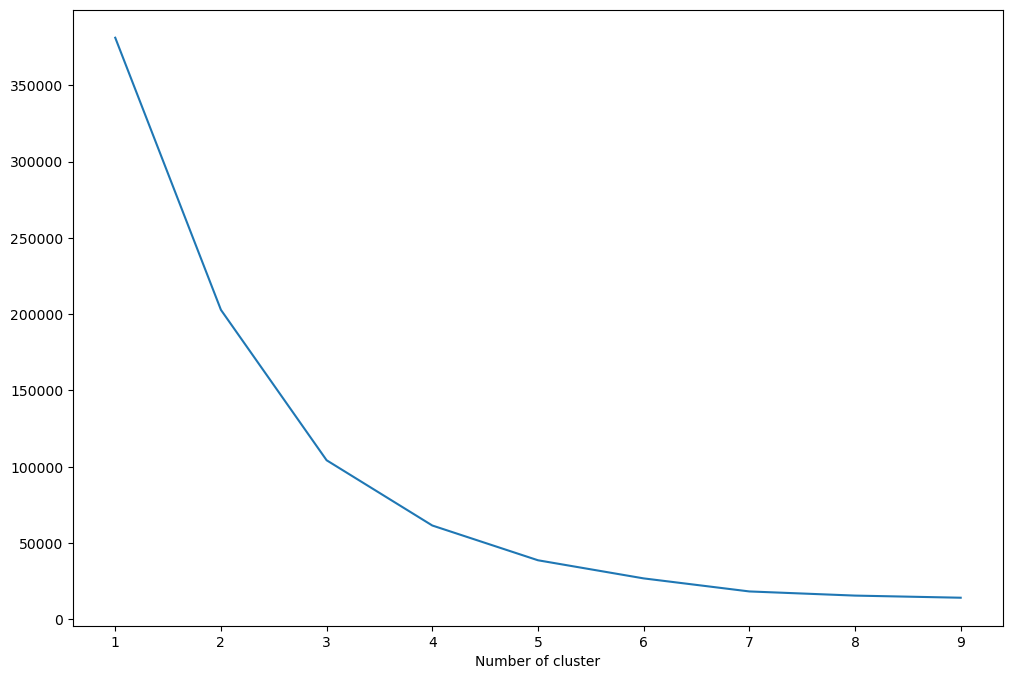

In [41]:
plt.figure(figsize=(12,8))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.show()

In [42]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(customer[['Frequency']])

customer['FrequencyCluster'] = kmeans.predict(customer[['Frequency']])

In [43]:
customer = order_cluster('FrequencyCluster', 'Frequency', customer, True)

In [44]:
customer.groupby('FrequencyCluster')['Frequency'].describe()

,count,mean,std,min,25%,50%,75%,max
FrequencyCluster,,,,,,,,
0,3755.0,2.816511,1.976997,1.0,1.0,2.0,4.00,8.0
1,574.0,15.052265,6.286698,9.0,10.0,13.0,18.00,36.0
2,40.0,58.325000,22.847754,38.0,43.0,51.5,63.75,128.0
3,3.0,213.666667,40.501029,169.0,196.5,224.0,236.00,248.0


In [45]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(customer[['Monetary']])

customer['MonetaryCluster'] = kmeans.predict(customer[['Monetary']])

In [46]:
customer = order_cluster('MonetaryCluster', 'Monetary', customer, True)

In [47]:
customer.groupby('MonetaryCluster')['Monetary'].describe()

,count,mean,std,min,25%,50%,75%,max
MonetaryCluster,,,,,,,,
0,4329.0,1347.622983,1994.067733,-4287.63,291.0000,640.500,1550.8500,17588.26
1,36.0,35694.129167,14720.254051,18573.68,24695.2375,30800.450,50894.9825,65892.08
2,4.0,114451.897500,19223.119671,88125.38,107069.4500,118554.795,125937.2425,132572.62
3,3.0,241136.560000,47874.073443,187482.17,221960.3300,256438.490,267963.7550,279489.02


In [48]:
customer['Score'] = (
    customer['RecencyCluster'] +
    customer['FrequencyCluster'] +
    customer['MonetaryCluster'])

In [49]:
customer.groupby('Score').count()

,Recency,Frequency,Monetary,RecencyCluster,FrequencyCluster,MonetaryCluster
Score,,,,,,
0,491,491,491,491,491,491
1,607,607,607,607,607,607
2,936,936,936,936,936,936
3,1773,1773,1773,1773,1773,1773
4,505,505,505,505,505,505
5,34,34,34,34,34,34
6,18,18,18,18,18,18
7,4,4,4,4,4,4
8,4,4,4,4,4,4


In [50]:
def segment(score):

    if score <= 1:
        return 'Low-Value'

    elif score > 1 and score <= 4:
        return 'Average'

    elif score > 4 and score <= 6:
        return 'Potential'

    else:
        return 'High-Value'

In [51]:
customer['SEGMENT'] = customer['Score'].apply(segment)

In [52]:
customer.head()

,Recency,Frequency,Monetary,RecencyCluster,FrequencyCluster,MonetaryCluster,Score,SEGMENT
0,327,2,0.00,0,0,0,0,Low-Value
1,2,7,4310.00,3,0,0,3,Average
2,75,4,1797.24,2,0,0,2,Average
3,19,1,1757.55,3,0,0,3,Average
4,311,1,334.40,0,0,0,0,Low-Value


In [53]:
customer.groupby('SEGMENT').count()

,Recency,Frequency,Monetary,RecencyCluster,FrequencyCluster,MonetaryCluster,Score
SEGMENT,,,,,,,
Average,3214,3214,3214,3214,3214,3214,3214
High-Value,8,8,8,8,8,8,8
Low-Value,1098,1098,1098,1098,1098,1098,1098
Potential,52,52,52,52,52,52,52


In [56]:
customer = order_cluster('RecencyCluster', 'Recency', customer, False)

In [57]:
customer = order_cluster('FrequencyCluster', 'Frequency', customer, True)

In [58]:
customer = order_cluster('MonetaryCluster', 'Monetary', customer, True)

In [59]:
def segment(score):

    if score <= 1:
        return 'Low-Value'

    elif score > 1 and score <= 4:
        return 'Average'

    elif score > 4 and score <= 6:
        return 'Potential'

    else:
        return 'High-Value'

In [60]:
customer['SEGMENT'] = customer['Score'].apply(segment)

In [61]:
customer.head()

,Recency,Frequency,Monetary,Score,SEGMENT,RecencyCluster,FrequencyCluster,MonetaryCluster
0,327,2,0.00,0,Low-Value,0,0,0
1,2,7,4310.00,3,Average,3,0,0
2,75,4,1797.24,2,Average,2,0,0
3,19,1,1757.55,3,Average,3,0,0
4,311,1,334.40,0,Low-Value,0,0,0


In [62]:
customer.groupby('SEGMENT').count()

,Recency,Frequency,Monetary,Score,RecencyCluster,FrequencyCluster,MonetaryCluster
SEGMENT,,,,,,,
Average,3214,3214,3214,3214,3214,3214,3214
High-Value,8,8,8,8,8,8,8
Low-Value,1098,1098,1098,1098,1098,1098,1098
Potential,52,52,52,52,52,52,52


In [63]:
plt.style.use('bmh')

In [64]:
customer = customer[customer['Recency'] < 400]

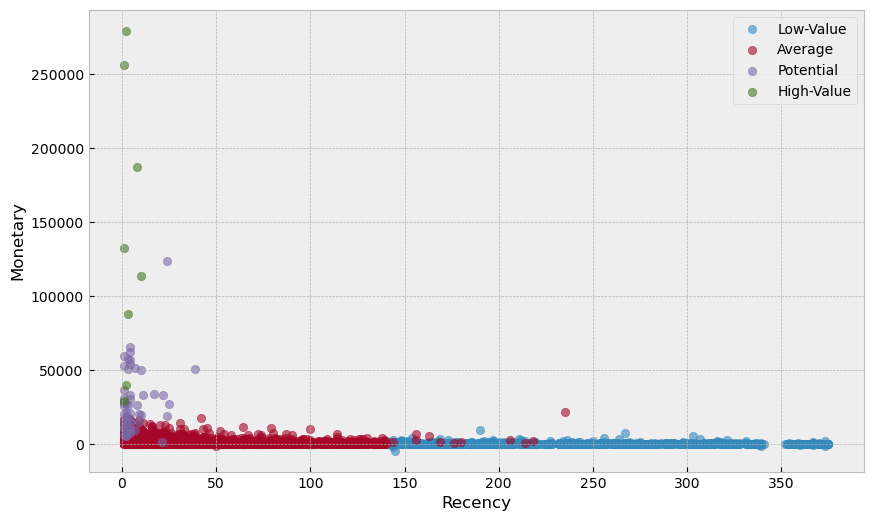

In [65]:
plt.figure(figsize=(10,6))

for segment in customer['SEGMENT'].unique():

    temp = customer[customer['SEGMENT'] == segment]

    plt.scatter(
        temp['Recency'],
        temp['Monetary'],
        label=segment,
        alpha=0.6
    )

plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend()
plt.show()

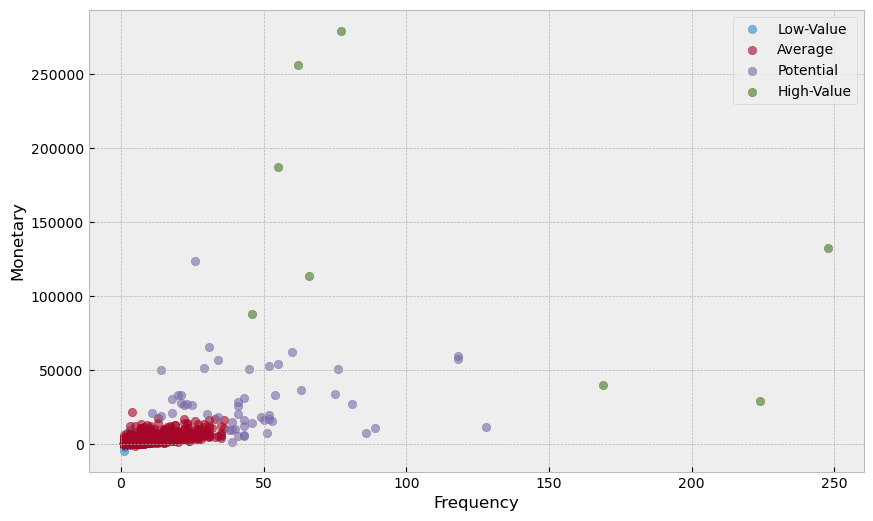

In [66]:
plt.figure(figsize=(10,6))

for segment in customer['SEGMENT'].unique():

    temp = customer[customer['SEGMENT'] == segment]

    plt.scatter(
        temp['Frequency'],
        temp['Monetary'],
        label=segment,
        alpha=0.6
    )

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.legend()
plt.show()

Se realizó una segmentación de clientes utilizando la metodología RFM (Recency, Frequency, Monetary). Mediante el algoritmo K-Means se generaron clusters para cada una de las variables, lo que permitió identificar diferentes tipos de clientes según su comportamiento de compra.
Posteriormente se calculó un RFM Score combinando los clusters de las tres métricas y se clasificó a los clientes en cuatro segmentos: Low-Value, Average, Potential y High-Value.
Los resultados muestran que la mayoría de los clientes pertenecen al segmento Average, mientras que un número muy pequeño corresponde a clientes High-Value, los cuales representan oportunidades importantes para estrategias de fidelización y marketing